In [1]:
from collections import defaultdict
from collections import OrderedDict
import numpy as np
import matchms
from matchms import Spectrum
from matchms.importing import load_from_mgf, load_from_msp
from matchms.exporting import save_as_mgf

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from matchms import set_matchms_logger_level
set_matchms_logger_level("ERROR")

In [3]:
def plot_number_fragments(consensus_spectra, bins=1000):
    n_peaks = [len(spec.peaks.mz) for spec in consensus_spectra]

    plt.figure(figsize=(10, 6))
    ax = sns.histplot(n_peaks, bins=bins)
    
    # Get the actual y-axis limit after plotting
    _, ymax = ax.get_ylim()
    
    # Plot mean and median lines using dynamic ymax
    plt.vlines(x=np.mean(n_peaks), ymin=0, ymax=ymax, color="red", label=f"mean: {round(np.mean(n_peaks),2)}")
    plt.vlines(x=np.median(n_peaks), ymin=0, ymax=ymax, color="orange", label=f"median: {np.median(n_peaks)}")
    
    plt.xlim(0, 300)
    plt.legend()
    plt.show()


In [4]:
def make_consensus_spectra(spectra):
    """Combine spectra with the same compound ID by summing their peaks and normalizing."""
    
    # Step 1: Group spectra by compound ID
    spectra_dict = defaultdict(list)
    
    for spectrum in spectra: # this needs to be on the same level as the other for loop
        compound_id = spectrum.metadata.get("inchikey") 
        
        if compound_id is not None:
            spectra_dict[compound_id[:14]].append(spectrum)
        else:
            print("No inchikey. Should not happen in combined libraries")

    # Step 2: Combine spectra
    combined_spectra = []
    
    for compound_id, spec_list in spectra_dict.items():
        mz_intensity_dict = defaultdict(float, OrderedDict()) 
        mz_count_dict = defaultdict(int, OrderedDict())  # new
        inchikey = spec_list[0].get("inchikey")
        smiles = spec_list[0].get("smiles")
        formula = spec_list[0].get("formula")
        precursor_formula = spec_list[0].get("precursor_formula")
        adduct = spec_list[0].get("adduct")
        instrument_type = spec_list[0].get("instrument_type")
        collision_energy = spec_list[0].get("collision_energy")
        precursor_mz = spec_list[0].get("precursor_mz")

        # Sum up intensities for each m/z value
        for spectrum in spec_list:
            mz_values, intensities = [round(peak, 2) for peak in spectrum.peaks.mz], spectrum.peaks.intensities
            for mz, intensity in zip(mz_values, intensities):
                mz_intensity_dict[mz] += intensity  # Sum up intensities
                mz_count_dict[mz] += 1 # new

        intensities = []
        mzs = []
        threshold = len(spec_list) / 4 # new
        for mz, count in mz_count_dict.items():
               if count >= threshold:
                   mzs.append(mz)
                   intensity = mz_intensity_dict[mz]
                   intensities.append(intensity / count)

        if mzs:
            mzs, intensities = zip(*sorted(zip(mzs, intensities)))  
            mzs = np.array(mzs)
            intensities = np.array(intensities) / np.max(intensities)  # Normalize
    
            # Create new Spectrum object
            new_spectrum = Spectrum(mz=mzs, intensities=intensities, # modified
                                    metadata={
                                        "matching_index": inchikey,
                                        "inchikey": inchikey,
                                        "smiles": smiles,
                                        "formula": formula,
                                        "precursor_formula": precursor_formula,
                                        "adduct": adduct,
                                        "instrument_type": instrument_type,
                                        "collision_energy": collision_energy,
                                        "precursor_mz": precursor_mz,
                                        
                                    })
            combined_spectra.append(new_spectrum)
        else:
            print("No common mz values:", smiles)
        
    return combined_spectra

## Create Consensus WFSR Library

In [5]:
wfsr_library = list(load_from_msp("../../../../DATASETS/WFSR_Library_External_V3.25_MLready.msp"))

In [6]:
len(wfsr_library)

6993

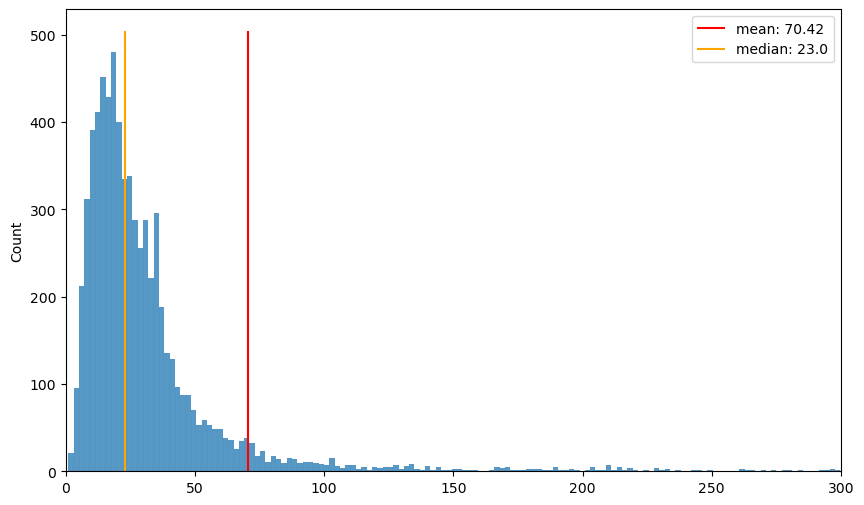

In [7]:
plot_number_fragments(wfsr_library, 5000)

In [8]:
wfsr_consensus_library = make_consensus_spectra(wfsr_library)

In [9]:
len(wfsr_consensus_library)

959

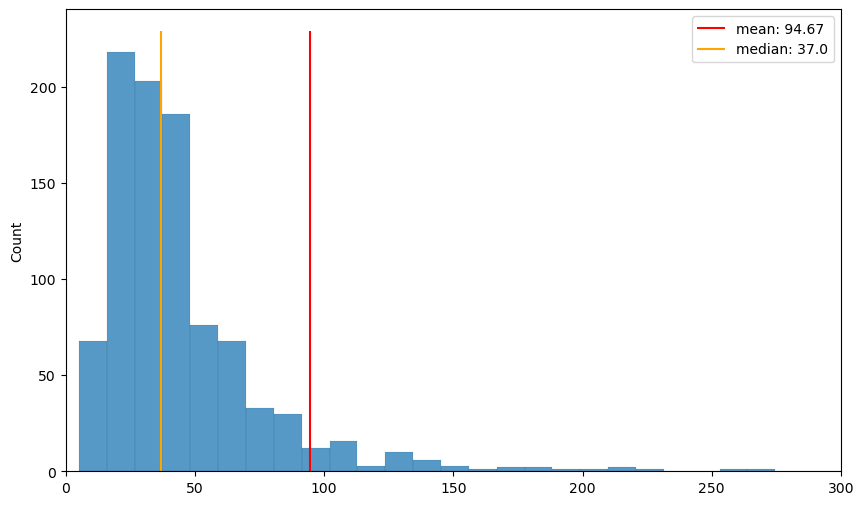

In [10]:
plot_number_fragments(wfsr_consensus_library)

---

## Consensus Massbank Orbitrap Library

In [11]:
mb_orbi = list(load_from_msp("../../../../DATASETS/massbank_OnlyOrbitrap_20250408.msp"))

In [12]:
len(mb_orbi)

27262

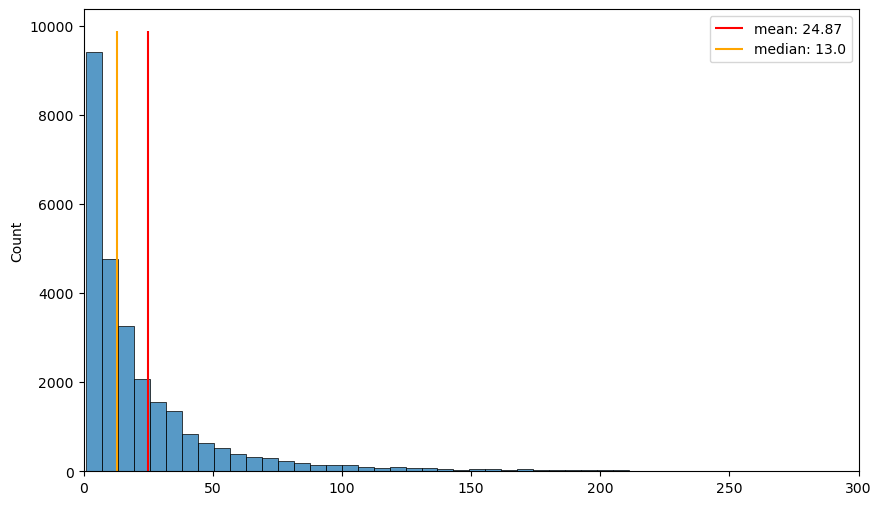

In [13]:
plot_number_fragments(mb_orbi, 100)

In [14]:
mb_orbi_consensus_spectra = make_consensus_spectra(mb_orbi)

No inchikey. Should not happen in combined libraries
No inchikey. Should not happen in combined libraries
No inchikey. Should not happen in combined libraries
No inchikey. Should not happen in combined libraries
No inchikey. Should not happen in combined libraries
No inchikey. Should not happen in combined libraries
No inchikey. Should not happen in combined libraries
No inchikey. Should not happen in combined libraries
No inchikey. Should not happen in combined libraries
No inchikey. Should not happen in combined libraries
No inchikey. Should not happen in combined libraries
No inchikey. Should not happen in combined libraries
No inchikey. Should not happen in combined libraries
No inchikey. Should not happen in combined libraries
No inchikey. Should not happen in combined libraries
No inchikey. Should not happen in combined libraries
No inchikey. Should not happen in combined libraries
No inchikey. Should not happen in combined libraries
No inchikey. Should not happen in combined lib

In [15]:
len(mb_orbi_consensus_spectra)

2494

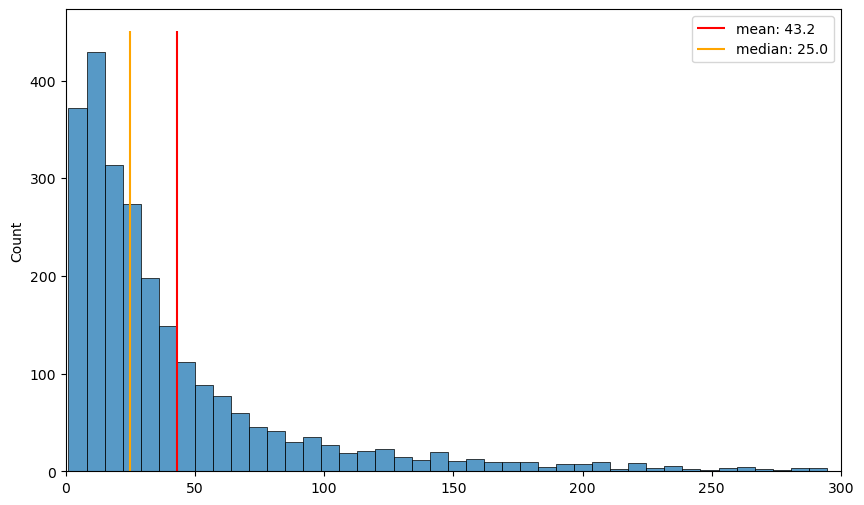

In [16]:
plot_number_fragments(mb_orbi_consensus_spectra, 100)

---

## Consensus Massbank TOF Library

In [17]:
mb_tof = list(load_from_msp("../../../../DATASETS/massbank_OnlyTOF_20250408.msp"))

In [18]:
len(mb_tof)

32560

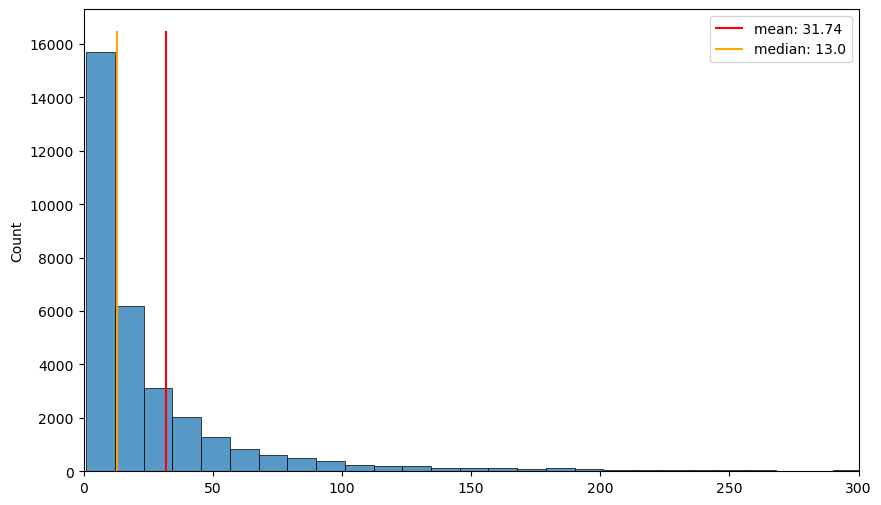

In [19]:
plot_number_fragments(mb_tof, 100)

In [20]:
mb_tof_consensus_spectra = make_consensus_spectra(mb_tof)

No inchikey. Should not happen in combined libraries
No inchikey. Should not happen in combined libraries
No inchikey. Should not happen in combined libraries
No inchikey. Should not happen in combined libraries
No inchikey. Should not happen in combined libraries
No inchikey. Should not happen in combined libraries
No inchikey. Should not happen in combined libraries
No inchikey. Should not happen in combined libraries
No inchikey. Should not happen in combined libraries
No inchikey. Should not happen in combined libraries
No inchikey. Should not happen in combined libraries
No inchikey. Should not happen in combined libraries
No inchikey. Should not happen in combined libraries
No inchikey. Should not happen in combined libraries
No inchikey. Should not happen in combined libraries
No inchikey. Should not happen in combined libraries
No inchikey. Should not happen in combined libraries
No inchikey. Should not happen in combined libraries
No inchikey. Should not happen in combined lib

In [21]:
len(mb_tof_consensus_spectra)

3640

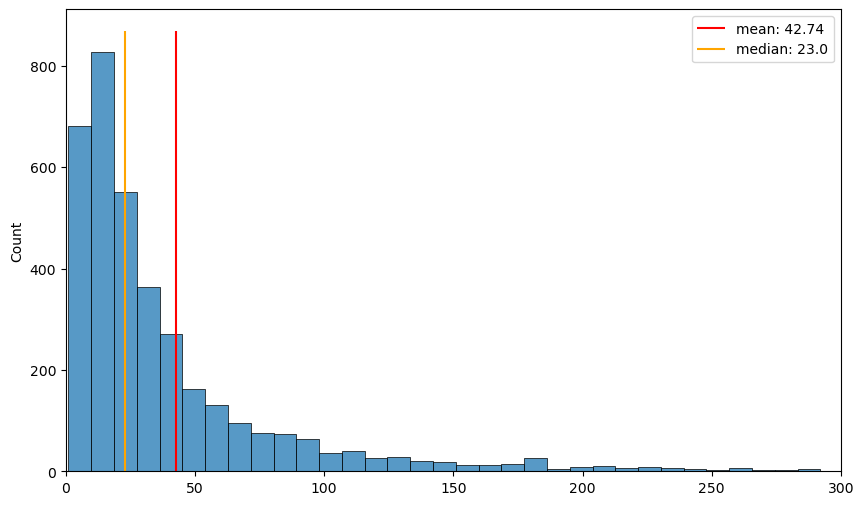

In [22]:
plot_number_fragments(mb_tof_consensus_spectra, 100)

---

## Consensus Lib 3: WFSR + Orbitrap + TOF + GNPS

In [23]:
Lib3_WFSR_mbOrbitrap_mbTOF = list(load_from_mgf("../1_CombinedLibraries/Lib3_WFSR_mbOrbitrap_mbTOF.mgf"))

In [24]:
Lib3_WFSR_mbOrbitrap_mbTOF_consensus_spectra = make_consensus_spectra(Lib3_WFSR_mbOrbitrap_mbTOF)

In [25]:
len(Lib3_WFSR_mbOrbitrap_mbTOF_consensus_spectra)

5206

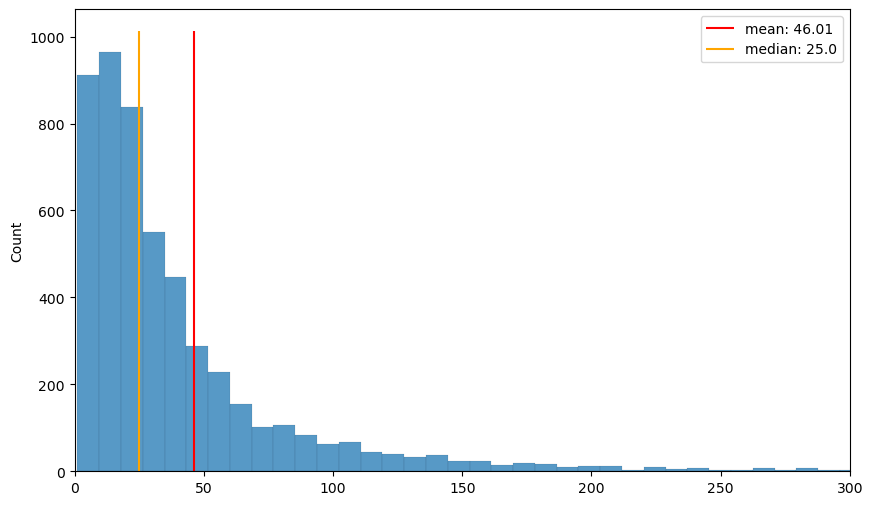

In [26]:
plot_number_fragments(Lib3_WFSR_mbOrbitrap_mbTOF_consensus_spectra, 1000)

In [27]:
save_as_mgf(Lib3_WFSR_mbOrbitrap_mbTOF_consensus_spectra, "Lib3_WFSR_mbOrbitrap_mbTOF_consensus.mgf")

dict_keys(['spectra'])


---